# LTLf synthesis with unobservable variables

In [1]:
import spot
spot.setup(show_default='.A') # Don't show acceptance conditions in twa, since we abuse twa to represent DFA

The following specification states that assuming `u` alternate between on and off (but we do not know its initial value), we eventually want that `o=u`.   This is realizable, for instance by a controller that continuously assign the same value to o.

In [2]:
f = 'G((!u | X!u) & (u | Xu)) -> X[!]F(u <-> o)'
out = ['o']
unobs = [spot.formula.ap('u')]

Here is the automaton for `f` as an MTDFA, or as a DFA.

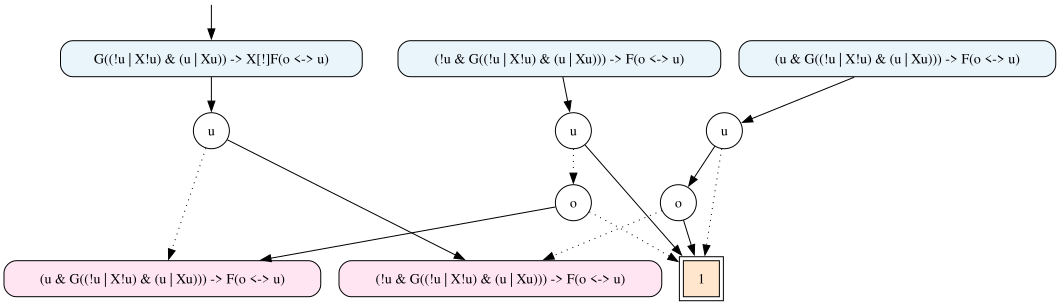

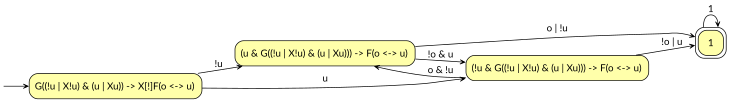

In [3]:
a = spot.ltlf_to_mtdfa(f); display(a); display(a.as_twa(True))

In order to consider `u` as unobservable, we quantify it away.

In [4]:
qf = spot.formula.forall(unobs, f)
display(qf)

spot.formula("\\forall u: (G((!u | X!u) & (u | Xu)) -> X[!]F(o <-> u))")

Here is the game generated for synthesis.  By comparing the labels of the states in this game and the previous one, we can see that `u` was quantified universally by replacing all `u`-labeled nodes by the conjunction of their children.

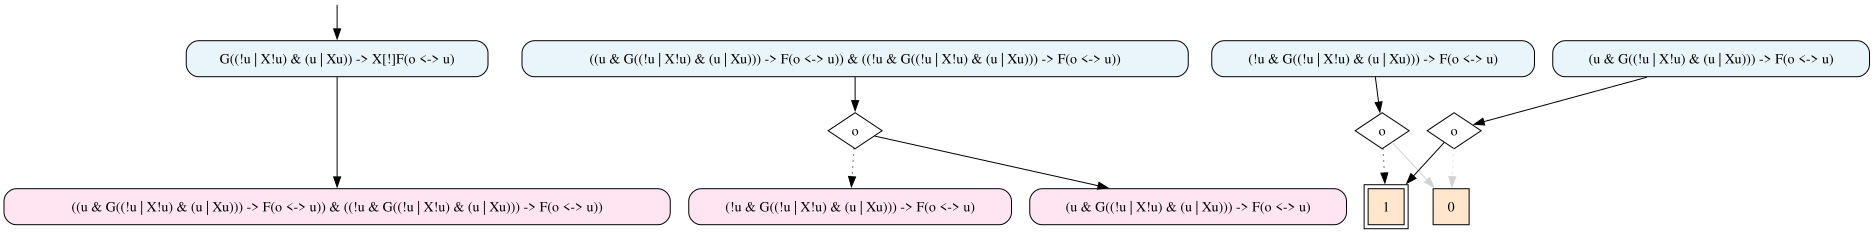

In [5]:
spot.ltlf_to_mtdfa_for_synthesis(qf, out, 
                                 approach="state_refine")  # slight simplifications, but no solving

Now, the solved version, and its corresponding Mealy machine:

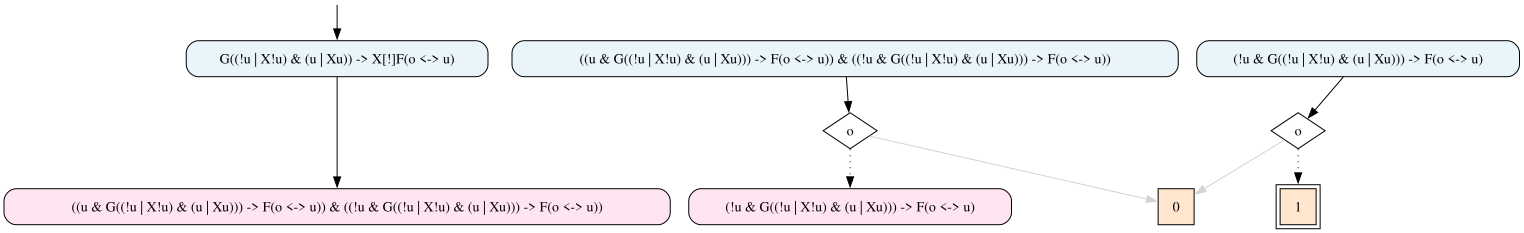

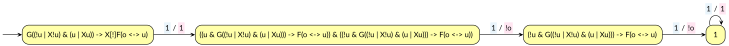

In [6]:
strat = spot.ltlf_to_mtdfa_for_synthesis(qf, out)
display(strat)
display(spot.mtdfa_strategy_to_mealy(strat))

Note that the above example has no observable input variables, so we do not have to order input and output variables to decide between Moore and Mealy semantics.  (See the [ltlf2dfa notebook](https://spot.lre.epita.fr/ipynb/ltlf2dfa.html#Game-interpretation) for how to do that.)

# LTL synthesis with unobserved variables

Universal quantification is not straightfoward for ω-automata, so instead we translate the complemented formula, perform _existential_ quantification, and determinize the result to complement it as a DPA.

This currently only supports Mealy semantics.

In [7]:
from spot.jupyter import display_inline
import buddy
spot.setup(show_default='.a') # Print acceptance conditions again.

In [8]:
def synt_w_unobs(f, out, unobs):
    quant_nba_neg = spot.translate(spot.formula.exists(unobs, spot.formula_Not(f)))
    display_inline("negated NBA after ∃-quantification:", quant_nba_neg)
    dpa_neg = spot.tgba_determinize(quant_nba_neg)
    display_inline("negated DPA:", dpa_neg)
    dpa = spot.dualize(dpa_neg)
    display_inline("DPA:", dpa)
    b = buddy.bddtrue
    for o in out:
        b &= buddy.bdd_ithvar(dpa.register_ap(o))
    dpa.set_synthesis_outputs(b)
    game = spot.split_2step(dpa)
    res = spot.solve_game(game)
    spot.highlight_strategy(game)
    display_inline("game:", game)
    display("REALIZABLE" if res else "UNREALIZABLE")
    if res:
        mealy = spot.solved_game_to_mealy(game)
        mealy = spot.unsplit_mealy(mealy)
        display_inline("Mealy controller:", mealy)
        spot.simplify_mealy_here(mealy, 2, False)
        display_inline("simplified Mealy controller:", mealy)

In [9]:
synt_w_unobs('G((!u | X!u) & (u | Xu)) -> X[!]F(u <-> o)', out = ['o'], unobs = unobs)

'REALIZABLE'

Let's change this a an unrealizable specification.

In [10]:
synt_w_unobs('G(u <-> X!u) & XF(u <-> o)', out = ['o'], unobs = unobs)

'UNREALIZABLE'

There is also a shortcut to convert LTL into a Game, with a few extra simplifaction along the way.  That is actually what is used in `ltlsynt`.  This `ltl_to_game()` function takes an optional list of unobservable variables to quantify universally, and will take care of doing the negation/∃-quantification/complementation.   The only downside
is that you currently have to configure it to use `DET_SPLIT` or `SPLIT_DET` instead of more efficient approaches like LAR or ACD.  (This should be fixed eventually.)

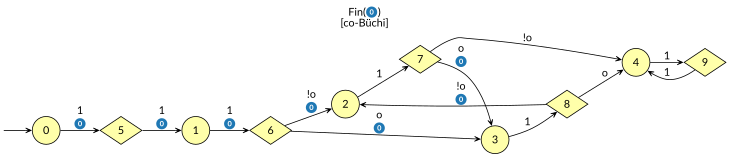

In [11]:
si = spot.synthesis_info()
si.s = spot.synthesis_info.algo_DET_SPLIT
spot.ltl_to_game('G(u <-> X!u) -> XF(u <-> o)', ['o'], si, ['u'])

Whith that function, our synthesis function can be simplified to this:

In [12]:
def synt_w_unobs2(f, out, unobs):
    si = spot.synthesis_info()
    si.s = spot.synthesis_info.algo_DET_SPLIT
    game = spot.ltl_to_game(f, out, si, unobs)
    res = spot.solve_game(game)
    spot.highlight_strategy(game)
    display_inline("game:", game)
    display("REALIZABLE" if res else "UNREALIZABLE")
    if res:
        mealy = spot.solved_game_to_mealy(game)
        mealy = spot.unsplit_mealy(mealy)
        display_inline("Mealy controller:", mealy)
        spot.simplify_mealy_here(mealy, 2, False)
        display_inline("simplified Mealy controller:", mealy)

In [13]:
synt_w_unobs2('G(u <-> X!u) -> XF(u <-> o)', out = ['o'], unobs = ['u'])

'REALIZABLE'